#### Keras를 이용한 손글씨 인식 딥러닝
- Tensorflow로 작성된 프로그램은 sklearn보다 어려움
- Keras는 테아노(Theano)와 Tensorflow를 Wrapping한 라이브러리

----
##### Data 불러오기

In [1]:
import pandas as pd

In [6]:
train = pd.read_csv('Data/HandWriting/train_20k.csv', header = None)
train.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
test = pd.read_csv('Data/HandWriting/test_1k.csv', header = None)
test.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



----
##### 전처리(Pre-processing)

In [10]:
# shape 확인 -> data + label 같이 있음
print(train.shape)
print(test.shape)

(20001, 785)
(1001, 785)


In [21]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20001 entries, 0 to 20000
Columns: 785 entries, 0 to 784
dtypes: int64(785)
memory usage: 119.8 MB


In [27]:
# 결측치 확인
train.isna().sum()

0      0
1      0
2      0
3      0
4      0
      ..
780    0
781    0
782    0
783    0
784    0
Length: 785, dtype: int64

In [ ]:
# Target 데이터의 비율 확인
# label의 분포가 고루되어 있어야 학습이 잘됨
import numpy as np

checkCount = np.unique(train[0], return_counts= True)[1]

# target 데이터 분포 확인
# 최소 60% 이상 나와야 target 데이터가 고루 분포되어 있다고 할 수 있음
np.min(checkCount) / np.max(checkCount)

np.float64(0.7786058746163963)

##### dataset : feature / target 분리 -> 정규화

In [42]:
train_target = train[0]
train_input = train.iloc[:, 1:]

In [43]:
test_target = test[0]
test_input = test.iloc[:, 1:]

In [37]:
print(test_input.shape, test_target.shape)

(1001, 784) (1001,)


In [46]:
# 정규화
train_input = train_input / 255.0
test_input = test_input / 255.0

In [48]:
train_input.describe()

,1,2,3,4,5,6,7,8,9,10,...,775,776,777,778,779,780,781,782,783,784
count,20001.0,20001.0,20001.0,20001.0,20001.0,20001.0,20001.0,20001.0,20001.0,20001.0,...,20001.000000,20001.000000,20001.000000,20001.000000,20001.000000,20001.000000,20001.0,20001.0,20001.0,20001.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000747,0.000500,0.000295,0.000185,0.000128,0.000012,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.023439,0.018208,0.015080,0.010991,0.008963,0.001719,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.996078,0.996078,0.992157,0.992157,0.956863,0.243137,0.0,0.0,0.0,0.0


----
#### Deep Learning Model 만들기

In [49]:
from tensorflow import keras
from tensorflow.keras.layers import Input

In [50]:
# 모델 생성
model = keras.Sequential()
model.add(Input(shape = (784,)))                            # 입력층
model.add(keras.layers.Dense(100, activation='relu'))       # 은닉층
model.add(keras.layers.Dense(10, activation= 'softmax'))    # 출력층

# 손실함수
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [51]:
# 모델 훈련하기
model.fit(
    np.array(train_input),
    np.array(train_target),
    epochs = 10,
)

Epoch 1/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8840 - loss: 0.4180
Epoch 2/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9398 - loss: 0.2087
Epoch 3/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9575 - loss: 0.1477
Epoch 4/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9688 - loss: 0.1112
Epoch 5/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9745 - loss: 0.0865
Epoch 6/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9816 - loss: 0.0683
Epoch 7/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9854 - loss: 0.0547
Epoch 8/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9881 - loss: 0.0428
Epoch 9/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9911 - loss: 0.0339
Epoch 10/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9933 - loss: 0.0283


----
#### 테스트 데이터로 평가

In [53]:
loss, score = model.evaluate(test_input, test_target)             # 출력 : [loss, accuracy]
print(f"loss : {loss}, score : {score}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9680 - loss: 0.1138
loss : 0.11375129967927933, score : 0.9680319428443909


----
#### 테스트 데이터로 predict 해보기

In [65]:
pred = model.predict(test_input)
print('test label', '\n', test_target[:10])
print('pred', '\n', np.argmax(pred[3]))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
test label 
 0    7
1    2
2    1
3    0
4    4
5    1
6    4
7    9
8    5
9    9
Name: 0, dtype: int64
pred 
 0


In [67]:
pred.shape

(1001, 10)

----
#### 사용 : Image 만들기

In [68]:
from PIL import Image

In [69]:
# train_data 크기
train.shape

(20001, 785)

In [70]:
# 0번의 정답을 제외한 데이터
train1 = train.loc[:, train.columns != 0]
train1.shape

(20001, 784)

In [72]:
# train1 데이터의 50번째로 이미지 만들기
abc = np.array(train1.iloc[50]).reshape(28, 28)
abc.shape

(28, 28)

In [74]:
# Image 만들기
img = Image.fromarray(abc.astype(np.uint8))
img

In [75]:
# image 저장하기
img.save('Data/mnist_test_3.jpg', "JPEG")

----
#### 이미지 불러서 Predict 해보기

In [77]:
# Image 불러오기
img = Image.open('Data/mnist_test_3.jpg')
img

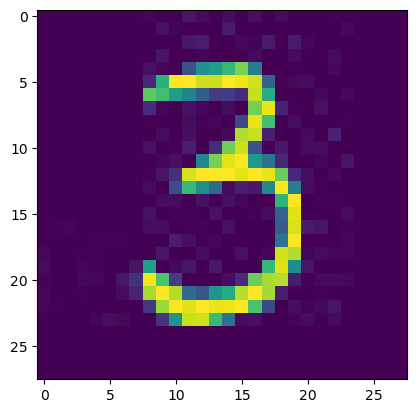

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.show()

In [83]:
# image를 numpy 배열로 변경하고 정규화하기
imgArray = np.array(img) / 255.0        # arrray로 바꾸고 정규화
imgArray

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.01176471, 0.        ,
        0.        , 0.05882353, 0.02352941, 0.        , 0.03137255,
        0.        , 0.03529412, 0.        , 0.02745098, 0.        ,
        0.        , 0.        , 0.00392157, 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.04313725,
        0.00784314, 0.        , 0.        , 0.        , 0.07058824,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.01960784, 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.0627451 , 0.0745098 , 0.        , 0.        ,
        0.01960784, 0.0078

In [84]:
imgArray.shape

(28, 28)

In [85]:
# 이미지 배열(2차원)을 1차원 배열로 변경
imgArray2 = imgArray.reshape(-1)
imgArray2.shape

(784,)

In [86]:
imgArray3 = imgArray2.tolist()
imgArray3

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.011764705882352941,
 0.0,
 0.0,
 0.058823529411764705,
 0.023529411764705882,
 0.0,
 0.03137254901960784,
 0.0,
 0.03529411764705882,
 0.0,
 0.027450980392156862,
 0.0,
 0.0,
 0.0,
 0.00392156862745098,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.043137254901960784,
 0.00784313725490196,
 0.0,
 0.0,
 0.0,
 0.07058823529411765,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0196078431372549,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.06274509803921569,
 0.07450980392156863,
 0.0,
 0.0,
 0.0196078431372549,
 0.00784313725490196,
 0.07058823529411765,
 0.0,
 0.07058823529411765,
 0.011764705882352941,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.050980392156862744,
 0.0,
 0.0,
 0.01568627450980392,
 0.0,
 0.0,
 0.0,
 0.023529411764705882,
 0.0,
 0.0,
 0.027450980392156862,
 0.0,
 0.0,
 0.02

In [88]:
dfArray = pd.DataFrame(imgArray3)
dfArray = dfArray.T                 # Transpose : 열 -> 행
dfArray

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.011765,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [89]:
print("예측값 : ", np.argmax(model.predict(dfArray), axis = 1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
예측값 :  [3]


----
#### train1 데이터의 150번째로 이미지 만들기

In [109]:
img_df = train1.loc[149, :]
img_df

1      0
2      0
3      0
4      0
5      0
      ..
780    0
781    0
782    0
783    0
784    0
Name: 149, Length: 784, dtype: int64

In [111]:
imgArray = np.array(img_df)
imgArray

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0, 101, 144, 253, 253, 255, 253, 253,
       253, 253, 255, 128,  25,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,  57, 163, 226, 249, 252, 252, 25

In [113]:
imgArray2 = imgArray.reshape(28, 28)
imgArray2.shape

(28, 28)

In [114]:
img = Image.fromarray(imgArray2.astype(np.uint8))
img

In [120]:
# 확인
print(train.iloc[149, :][0])

3


----
#### 딥러닝 구성
##### 딥러닝 신경망의 흐름
##### 1. 입력층(Input Layer)
- 입력 데이터를 받는층. 데이터는 보통 숫자로 변호나된 형태로
- 입력층은 데이터의 특징이나 변수를 신경망에 전달

##### 2. 은닉층(Hidden Layer)
- 입력층에서 받은 데이터를 처리하는 중간 단계
- 각 은닉층에서는 활성화 함수(Activation Function) 적용

##### 3. 출력층(Output Layer)
- 은닉층에서 전달된 데이터를 최종적으로 처리하여 결과를 내는 층
- 분류 문제라면 Softmax나 Sigmoid 활성화 함수가 사용되어 확률 계산

##### 4. 손실함수(Loss Function)
- 출력층에서 나온 결과와 실제 값(정답)을 비교하여 오류를 계산
- 손실함수는 예측이 얼마나 잘못됐는지 평가
- 대표적인 손실함수 : 회귀(MAE, RMSE), 분류(Cross Entropy)

##### 5. 최적화 함수(Optimization Function)
- 손실함수에서 계산된 오류를 바탕으로 네트워크의 가중치를 업데이트
- 대표적인 최적화 함수 : 확률적 경사하강법, Adam ...
- 최적화 함수는 역전파(Back Propagation) 과정에서 weight, bias 조절

> 위 과정을 여러번 반복 -> 신경망은 점점더 좋은 결과 도출